# Segmentacao de Imagens Coloridas por Agrupamento K-Means
**UFPI - Campus Senador Helvidio Nunes de Barros**  
**Disciplina:** Topicos Especiais em Visao Computacional - Prof. Jose Denes Lima Araujo  
**Grupo 4:** Segmentacao Baseada em Regiao (Secao 10.5 - Gonzalez & Woods, 4ª Edicao)  
**Parte Pratica:** Integrante 3 (Analise Experimental)

---

### Objetivo
Demonstrar a aplicacao do algoritmo de clustering K-Means para segmentacao de imagens coloridas utilizando o espaco de cores CIE L*a*b*, avaliando a variacao do parametro K (K = 2, 3 e 5) e evidenciando a ausencia de restricao espacial inerente ao metodo.


In [1]:
# Instalacao das dependencias para execucao no Google Colab
!pip install -q opencv-python numpy matplotlib scikit-image scipy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Importacao das bibliotecas necessarias
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 0.8

os.makedirs("imagens", exist_ok=True)
os.makedirs("resultados", exist_ok=True)

# Imagem de teste: borboleta sobre folhagem (contem fundo, vegetacao e objeto principal)
img_path = os.path.join("imagens", "cena_colorida.jpg")
if not os.path.exists(img_path):
    url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/butterfly.jpg"
    urllib.request.urlretrieve(url, img_path)
    print("Imagem baixada com sucesso:", img_path)
else:
    print("Imagem carregada localmente:", img_path)

Imagem carregada localmente: imagens\cena_colorida.jpg


### 1. Carregamento e Decomposicao no Espaco CIE L*a*b*
No espaco RGB padrao, variacoes de iluminacao afetam R, G e B simultaneamente.
No espaco CIE L*a*b*:
- **L\*:** Representa a luminancia (brilho, de 0 a 100).
- **a\*:** Eixo cromatico verde-vermelho.
- **b\*:** Eixo cromatico azul-amarelo.

Desacoplar o brilho da cor pura reduz a sensibilidade a sombras.


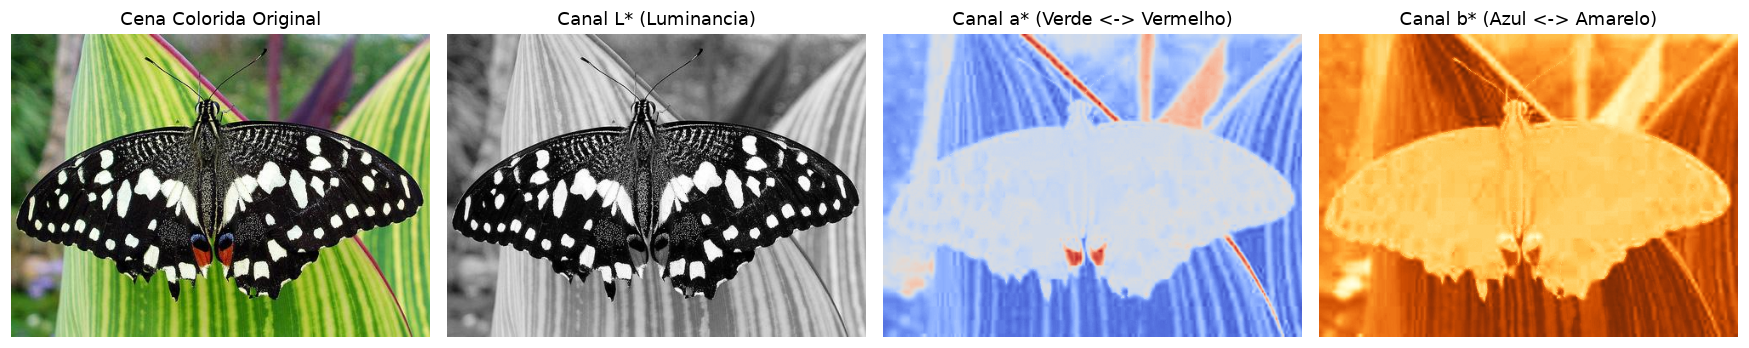

In [3]:
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(img_lab)

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Colorida Original")
ax[0].axis("off")

ax[1].imshow(L, cmap="gray")
ax[1].set_title("Canal L* (Luminancia)")
ax[1].axis("off")

ax[2].imshow(a, cmap="coolwarm")
ax[2].set_title("Canal a* (Verde <-> Vermelho)")
ax[2].axis("off")

ax[3].imshow(b, cmap="YlOrBr")
ax[3].set_title("Canal b* (Azul <-> Amarelo)")
ax[3].axis("off")

plt.tight_layout()
plt.show()


### 2. Implementacao Modular do K-Means
A funcao reestrutura a matriz tridimensional da imagem (Altura x Largura x 3) em uma matriz bidimensional (N x 3), onde N e o numero total de pixels.
Configuramos os criterios de parada do OpenCV (`cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER`) e executamos 10 tentativas com inicializacao aleatoria para evitar minimos locais.


In [4]:
def executar_kmeans(imagem_rgb, k, usar_lab=True, tentativas=10, max_iter=100, eps=0.2):
    """
    Executa o algoritmo K-Means no espaco de cores da imagem.
    
    Parametros:
      imagem_rgb: Matriz numpy RGB da imagem de entrada.
      k: Numero de clusters (grupos) desejados.
      usar_lab: Se True, converte para espaco CIE L*a*b* antes do agrupamento.
      tentativas: Quantidade de reinicializacoes com centroides aleatorios distintos.
      max_iter: Numero maximo de iteracoes por tentativa.
      eps: Deslocamento minimo dos centroides para declarar convergencia.
    """
    if usar_lab:
        img_espaco = cv2.cvtColor(imagem_rgb, cv2.COLOR_RGB2LAB)
    else:
        img_espaco = imagem_rgb.copy()
        
    H, W, C = img_espaco.shape
    # Reformata para matriz de amostras (N, 3) com tipo float32
    amostras = img_espaco.reshape((-1, 3)).astype(np.float32)
    
    # Criterio combinado: parar se atingir 100 iteracoes OU variacao < 0.2
    criterio = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, max_iter, eps)
    
    # Executa K-Means
    compactude, rotulos, centroides = cv2.kmeans(
        amostras, k, None, criterio, tentativas, cv2.KMEANS_RANDOM_CENTERS
    )
    
    # Converte os centroides de volta para inteiros de 8 bits
    centroides = np.uint8(centroides)
    
    # Reconstrói a imagem quantizada substituindo cada pixel pela cor do seu centroide
    imagem_quantizada = centroides[rotulos.flatten()].reshape((H, W, C))
    mapa_rotulos = rotulos.reshape((H, W))
    
    if usar_lab:
        imagem_quantizada_rgb = cv2.cvtColor(imagem_quantizada, cv2.COLOR_LAB2RGB)
    else:
        imagem_quantizada_rgb = imagem_quantizada
        
    return imagem_quantizada_rgb, mapa_rotulos, compactude, centroides

print("Funcao executar_kmeans pronta para uso.")


Funcao executar_kmeans pronta para uso.


### 3. Variacao do Parametro K (K = 2, 3 e 5)
Conforme proposto no trabalho:
- **K = 2:** Sub-segmentacao. Fundo e folhagem sao agrupados juntos; apenas o corpo da borboleta e separado.
- **K = 3:** Ponto de equilibrio. Isola os tres planos principais (fundo claro, folhagem verde e corpo da borboleta).
- **K = 5:** Sobre-segmentacao tonal. Divide a folha em multiplas faixas de gradientes.


Avaliacao da inercia intra-cluster (J) para cada K:
-> K = 2: Inercia J = 3.43e+08
-> K = 3: Inercia J = 1.83e+08
-> K = 5: Inercia J = 1.03e+08
Grafico comparativo salvo em: resultados\kmeans_comparativo_k.png


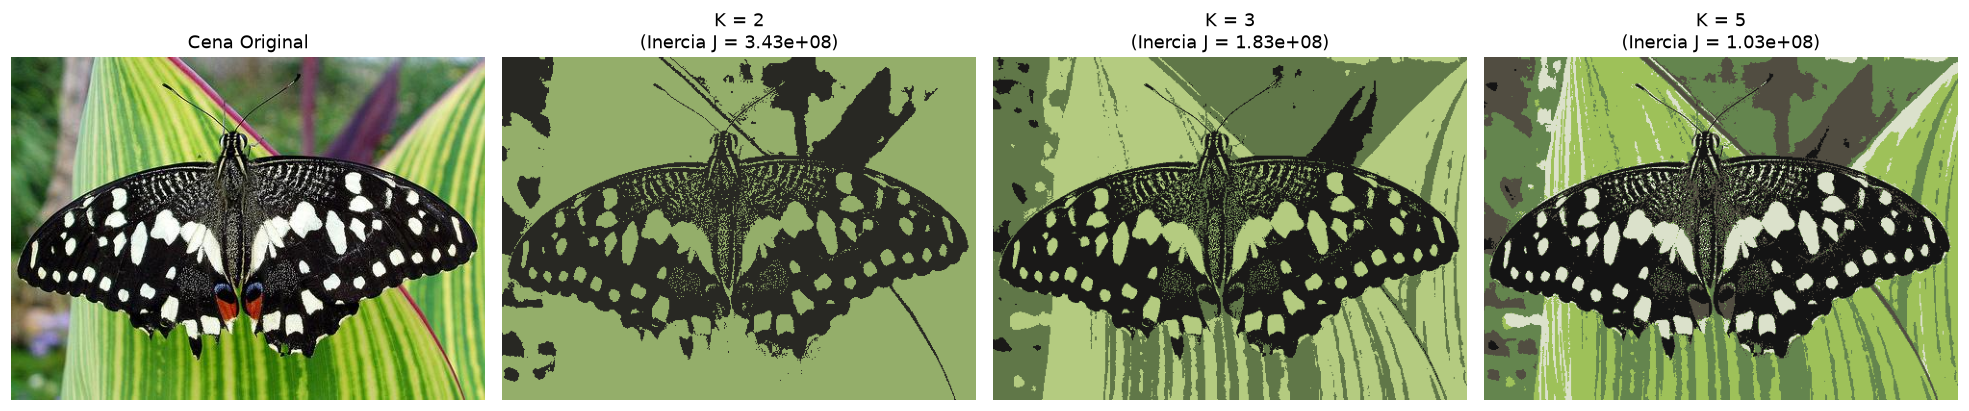

In [5]:
k_valores = [2, 3, 5]
resultados_k = {}

fig, ax = plt.subplots(1, 4, figsize=(18, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Original")
ax[0].axis("off")

print("Avaliacao da inercia intra-cluster (J) para cada K:")
for idx, k in enumerate(k_valores, 1):
    seg_rgb, lbl_img, J, cents = executar_kmeans(img_rgb, k, usar_lab=True)
    resultados_k[k] = (seg_rgb, lbl_img, J, cents)
    print(f"-> K = {k}: Inercia J = {J:.2e}")
    
    ax[idx].imshow(seg_rgb)
    ax[idx].set_title(f"K = {k}\n(Inercia J = {J:.2e})")
    ax[idx].axis("off")

plt.tight_layout()
out_k = os.path.join("resultados", "kmeans_comparativo_k.png")
plt.savefig(out_k, dpi=180, bbox_inches='tight')
print("Grafico comparativo salvo em:", out_k)
plt.show()


### 4. Analise Detalhada de K = 3 (Isolamento dos Planos)
Extraimos a mascara binaria de cada cluster e o recorte correspondente na imagem colorida para verificar quais regioes fisicas da cena foram agrupadas.


Cluster 1: 59071 pixels (33.7% da imagem)
Cluster 2: 66243 pixels (37.7% da imagem)
Cluster 3: 50194 pixels (28.6% da imagem)
Mascaras salvas em: resultados\kmeans_mascaras_k3.png


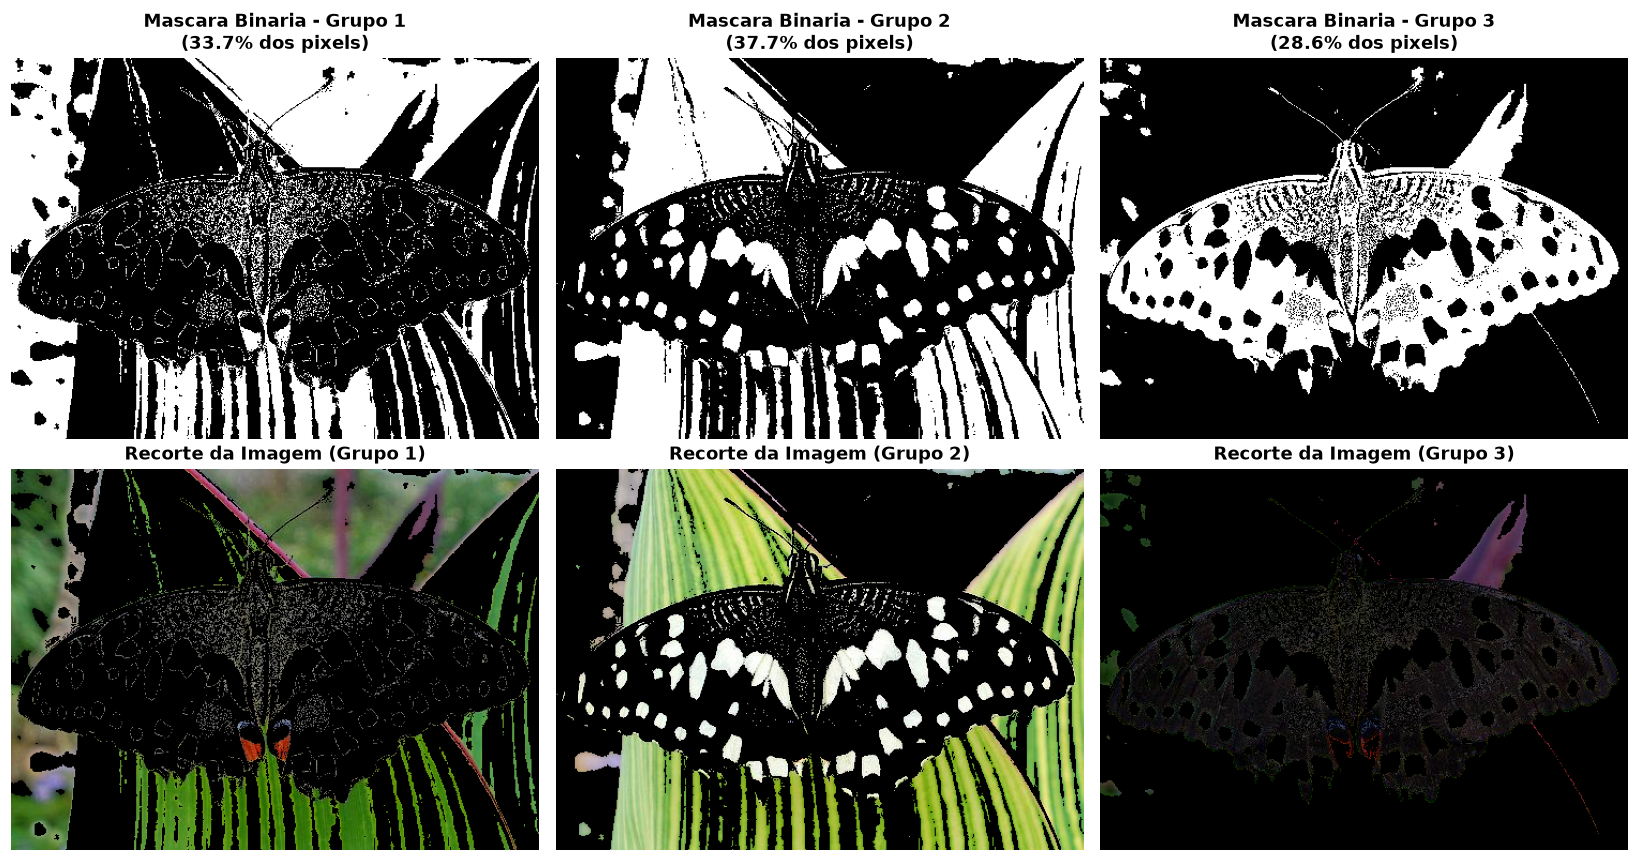

In [6]:
seg_k3, labels_k3, _, _ = resultados_k[3]
total_pixels = labels_k3.size

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for c in range(3):
    # Mascara booleana dos pixels pertencentes ao cluster c
    mask = (labels_k3 == c)
    pct = (np.sum(mask) / total_pixels) * 100
    print(f"Cluster {c+1}: {np.sum(mask)} pixels ({pct:.1f}% da imagem)")
    
    # Recorte isolado preservando apenas as cores deste cluster
    recorte = np.zeros_like(img_rgb)
    recorte[mask] = img_rgb[mask]
    
    axes[0, c].imshow(mask, cmap="gray")
    axes[0, c].set_title(f"Mascara Binaria - Grupo {c+1}\n({pct:.1f}% dos pixels)", fontweight='bold')
    axes[0, c].axis("off")
    
    axes[1, c].imshow(recorte)
    axes[1, c].set_title(f"Recorte da Imagem (Grupo {c+1})", fontweight='bold')
    axes[1, c].axis("off")

plt.tight_layout()
out_masc = os.path.join("resultados", "kmeans_mascaras_k3.png")
plt.savefig(out_masc, dpi=180, bbox_inches='tight')
print("Mascaras salvas em:", out_masc)
plt.show()


### 5. A Particularidade Pratica: Ausencia de Restricao Espacial
Ao analisar as mascaras geradas, nota-se que:
- O K-Means tradicional atua exclusivamente no espaco das cores (vetor 3D: L*, a*, b*). As coordenadas espaciais (x, y) nao sao consideradas.
- Por esse motivo, manchas brancas nas asas da borboleta e reflexos claros na folha ao fundo recebem o mesmo rotulo de cluster, apesar de estarem em posicoes espaciais completamente distantes.
- Essa limitacao e o motivo de Gonzalez & Woods apresentarem os **Superpixels (SLIC)** na 4ª edicao, que incorporam as coordenadas x e y formando um vetor 5D: `z = [L*, a*, b*, x, y]^T` para forcar contiguidade regional.


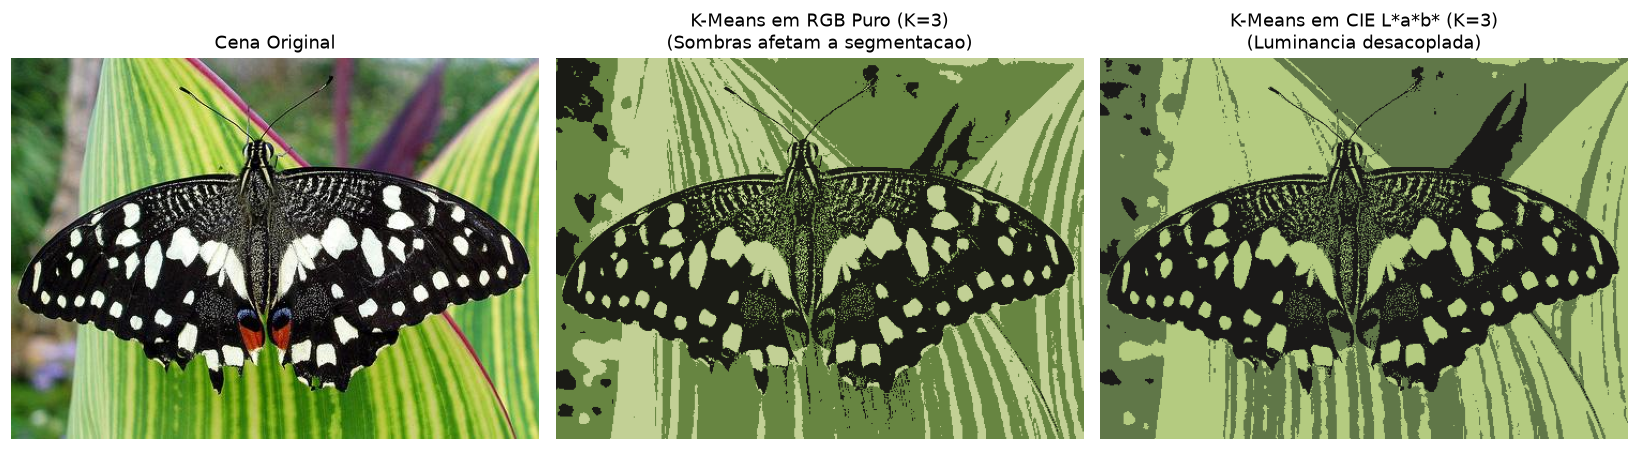

In [7]:
# Comparacao: K-Means em RGB puro vs K-Means em CIE L*a*b* (K = 3)
seg_rgb_puro, _, _, _ = executar_kmeans(img_rgb, 3, usar_lab=False)
seg_lab_puro, _, _, _ = executar_kmeans(img_rgb, 3, usar_lab=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(img_rgb)
ax[0].set_title("Cena Original")
ax[0].axis("off")

ax[1].imshow(seg_rgb_puro)
ax[1].set_title("K-Means em RGB Puro (K=3)\n(Sombras afetam a segmentacao)")
ax[1].axis("off")

ax[2].imshow(seg_lab_puro)
ax[2].set_title("K-Means em CIE L*a*b* (K=3)\n(Luminancia desacoplada)")
ax[2].axis("off")

plt.tight_layout()
plt.show()
